In [ ]:
import numpy as np
from matplotlib import pyplot as plt


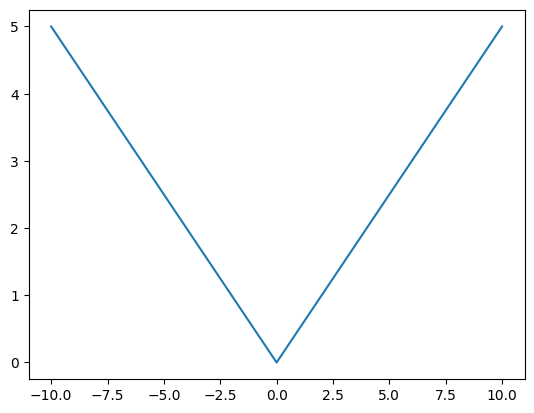

In [ ]:
N = 101
tau = (np.arange(N)+0.5)/N
xs = np.linspace(-10, 10, N)

rho = lambda y_true, y_pred : (0.5 - (y_true<y_pred))*(y_true-y_pred)

plt.plot(xs, rho(0, xs))

In [65]:
mog.draw_samples(2)

TypeError: multinomial() takes at least 2 positional arguments (1 given)

In [62]:
np.full(N, mog.draw_samples(1)[0])

TypeError: multinomial() takes at least 2 positional arguments (1 given)

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from learners import MixtureOfGaussians
mog = MixtureOfGaussians([1/2,1/2], [-2, 2], [1, 1], np.random.default_rng())
N = 9
tau = (np.arange(N)+0.5)/N

qs = mog.ppf(tau)
theta = qs

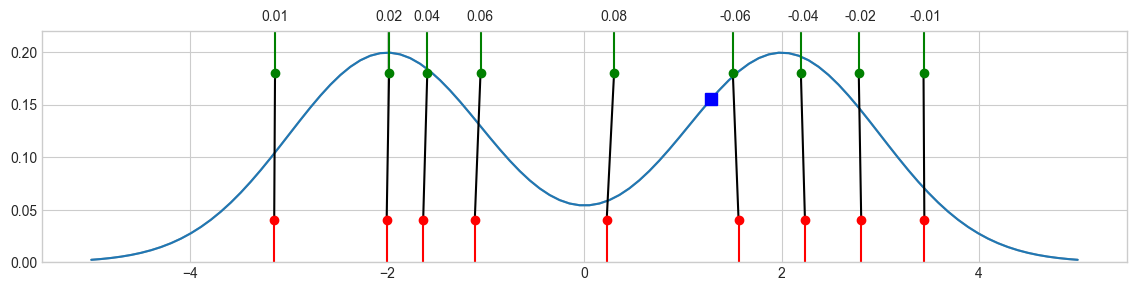

In [13]:
plt.style.use("seaborn-v0_8-whitegrid")

def rho_manual(Ttheta, theta, tau):
    N = len(Ttheta)
    g = np.zeros(N)
    for i in range(N):
        for j in range(N):
            u_ji = Ttheta[j] - theta[i]
            g[i] += -(tau[i] - (u_ji < 0)).astype(float) / N
    return g

for _ in range(100):
    sample = mog.draw_samples(1)[0]
    target = np.full(N, sample)
    # target = mog.draw_samples(N)
    theta_old = theta.copy()
    theta -= 0.15 * rho_manual(target, theta, tau)

xs = np.linspace(-5, 5, 100)
ys = mog.pdf(xs)
H = 0.2*ys.max()

plt.figure(figsize=(14,3))

plt.plot(xs, ys, color="gray", alpha=0.7)

roof = 0.22

plt.plot(xs, ys)

plt.plot([theta_old, theta], [H, roof-H], "black")

plt.plot([theta, theta], [roof, roof-H], "g")
plt.plot([theta], [roof-H], "og")

plt.plot([theta_old, theta_old], [0.0, H], "r")
plt.plot([theta_old], [H], "or");


plt.plot(sample, mog.pdf(sample), "sb", markersize=8)
# for sample in target:
#     plt.plot(sample, mog.pdf(sample), "sb", markersize=8)


diff = theta - theta_old

for i, q in enumerate(theta):
    plt.text(q-0.14, roof+0.01, diff.round(2)[i])

plt.ylim(0,roof)
plt.grid(True)